# Deep Neural Network for Breast Cancer Classification

# Load Dataset

https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [2]:
pip install ucimlrepo

In [7]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets




In [4]:
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
y.head()

,Diagnosis
0,M
1,M
2,M
3,M
4,M


<BarContainer object of 2 artists>

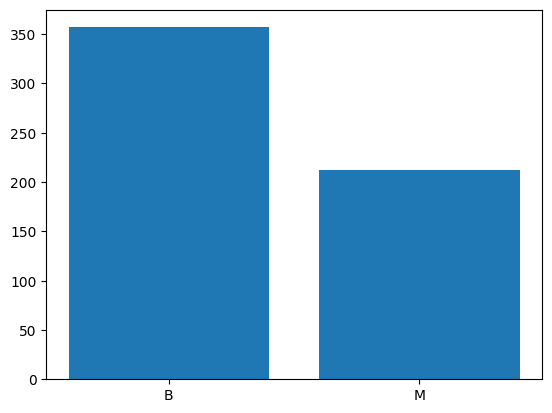

In [15]:
import matplotlib.pyplot as plt

plt.bar(y['Diagnosis'].value_counts().index, y['Diagnosis'].value_counts().values)


Note that the dataset is imbalanced, with more benign samples than malignant samples.

We will now process the data. Randomly choose 200 samples in 'M' (malignant) and 200 samples in 'B' (benign).

In [28]:
import pandas as pd

df = pd.concat([X,y], axis = 1)
df.sample(5)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
223,15.75,20.25,102.60,761.3,0.10250,0.12040,0.11470,0.06462,0.1935,0.06303,...,30.29,125.90,1088.0,0.1552,0.4480,0.39760,0.14790,0.3993,0.10640,M
300,19.53,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.10620,0.1792,0.06552,...,26.24,171.10,2053.0,0.1495,0.4116,0.61210,0.19800,0.2968,0.09929,M
506,12.22,20.04,79.47,453.1,0.10960,0.11520,0.08175,0.02166,0.2124,0.06894,...,24.17,85.13,515.3,0.1402,0.2315,0.35350,0.08088,0.2709,0.08839,B
533,20.47,20.67,134.70,1299.0,0.09156,0.13130,0.15230,0.10150,0.2166,0.05419,...,27.15,152.00,1645.0,0.1097,0.2534,0.30920,0.16130,0.3220,0.06386,M
173,11.08,14.71,70.21,372.7,0.10060,0.05743,0.02363,0.02583,0.1566,0.06669,...,16.82,72.01,396.5,0.1216,0.0824,0.03938,0.04306,0.1902,0.07313,B


In [29]:
data_B = df[df['Diagnosis']=='B']
data_M = df[df['Diagnosis']=='M']

data_B = data_B.sample(n=200 , random_state=42)
data_M = data_M.sample(n=200 , random_state=42)



In [30]:
df = pd.concat([data_B,data_M])
df.sample(5)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
463,11.60,18.36,73.88,412.7,0.08508,0.05855,0.03367,0.01777,0.1516,0.05859,...,24.02,82.68,495.1,0.13420,0.1808,0.1860,0.08288,0.3210,0.07863,B
298,14.26,18.17,91.22,633.1,0.06576,0.05220,0.02475,0.01374,0.1635,0.05586,...,25.26,105.80,819.7,0.09445,0.2167,0.1565,0.07530,0.2636,0.07676,B
204,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,0.06373,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
27,18.61,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,...,27.26,139.90,1403.0,0.13380,0.2117,0.3446,0.14900,0.2341,0.07421,M
36,14.25,21.72,93.63,633.0,0.09823,0.10980,0.13190,0.05598,0.1885,0.06125,...,30.36,116.20,799.6,0.14460,0.4238,0.5186,0.14470,0.3591,0.10140,M


<BarContainer object of 2 artists>

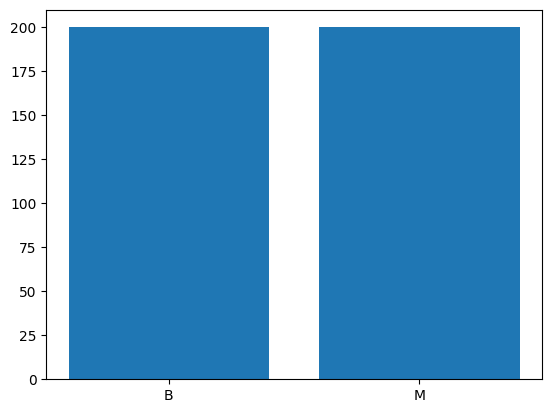

In [31]:
plt.bar(df['Diagnosis'].value_counts().index , df['Diagnosis'].value_counts().values)

Data Preprocessing
Before feeding the data into our neural network, we need to preprocess it. This involves separating the features and labels, splitting the data into training and test sets, and standardizing the feature values.

In [35]:
df

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
395,14.060,17.18,89.75,609.1,0.08045,0.05361,0.026810,0.03251,0.1641,0.05764,...,25.34,96.42,684.5,0.10660,0.12310,0.08460,0.07911,0.2523,0.06609,B
110,9.777,16.99,62.50,290.2,0.10370,0.08404,0.043340,0.01778,0.1584,0.07065,...,21.47,71.68,367.0,0.14670,0.17650,0.13000,0.05334,0.2533,0.08468,B
481,13.900,19.24,88.73,602.9,0.07991,0.05326,0.029950,0.02070,0.1579,0.05594,...,26.42,104.40,830.5,0.10640,0.14150,0.16730,0.08150,0.2356,0.07603,B
493,12.460,12.83,78.83,477.3,0.07372,0.04043,0.007173,0.01149,0.1613,0.06013,...,16.36,83.24,534.0,0.09439,0.06477,0.01674,0.02680,0.2280,0.07028,B
136,11.710,16.67,74.72,423.6,0.10510,0.06095,0.035920,0.02600,0.1339,0.05945,...,25.48,86.16,546.7,0.12710,0.10280,0.10460,0.06968,0.1712,0.07343,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,15.320,17.27,103.20,713.3,0.13350,0.22840,0.244800,0.12420,0.2398,0.07596,...,22.66,119.80,928.8,0.17650,0.45030,0.44290,0.22290,0.3258,0.11910,M
328,16.270,20.71,106.90,813.7,0.11690,0.13190,0.147800,0.08488,0.1948,0.06277,...,30.38,129.80,1121.0,0.15900,0.29470,0.35970,0.15830,0.3103,0.08200,M
199,14.450,20.22,94.49,642.7,0.09872,0.12060,0.118000,0.05980,0.1950,0.06466,...,30.12,117.90,1044.0,0.15520,0.40560,0.49670,0.18380,0.4753,0.10130,M
194,14.860,23.21,100.40,671.4,0.10440,0.19800,0.169700,0.08878,0.1737,0.06672,...,27.78,118.60,784.7,0.13160,0.46480,0.45890,0.17270,0.3000,0.08701,M


In [52]:

from sklearn.model_selection import train_test_split

X = df.drop(columns = 'Diagnosis')
Y = df['Diagnosis']

# Convert the targets to binary labels
Y = Y.map({'B': 0, 'M': 1})

display(X.sample(5))
display(Y.sample(5))

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
43,13.280,20.28,87.32,545.2,0.10410,0.14360,0.09847,0.061580,0.1974,0.06782,...,17.380,28.00,113.10,907.2,0.1530,0.3724,0.36640,0.14920,0.3739,0.10270
525,8.571,13.10,54.53,221.3,0.10360,0.07632,0.02565,0.015100,0.1678,0.07126,...,9.473,18.45,63.30,275.6,0.1641,0.2235,0.17540,0.08512,0.2983,0.10490
172,15.460,11.89,102.50,736.9,0.12570,0.15550,0.20320,0.109700,0.1966,0.07069,...,18.790,17.04,125.00,1102.0,0.1531,0.3583,0.58300,0.18270,0.3216,0.10100
313,11.540,10.72,73.73,409.1,0.08597,0.05969,0.01367,0.008907,0.1833,0.06100,...,12.340,12.87,81.23,467.8,0.1092,0.1626,0.08324,0.04715,0.3390,0.07434
412,9.397,21.68,59.75,268.8,0.07969,0.06053,0.03735,0.005128,0.1274,0.06724,...,9.965,27.99,66.61,301.0,0.1086,0.1887,0.18680,0.02564,0.2376,0.09206


,Diagnosis
504,0
388,0
230,1
535,1
327,0


In [53]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size= 0.2 , random_state=42 ,  stratify=Y)

display(f'X_train shape: {X_train.shape}')
display(f'y_train shape: {Y_train.shape}')
display(f'X_test shape: {X_test.shape}')
display(f'y_test shape: {Y_test.shape}')

'X_train shape: (320, 30)'

'y_train shape: (320,)'

'X_test shape: (80, 30)'

'y_test shape: (80,)'

Then we standardize the feature values using the StandardScaler from scikit-learn.

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
scalar.mean_

array([1.47316469e+01, 1.99757500e+01, 9.62140625e+01, 7.13163125e+02,
       9.75805937e-02, 1.11624281e-01, 1.03237637e-01, 5.67038406e-02,
       1.83699688e-01, 6.27365000e-02, 4.48022500e-01, 1.22888750e+00,
       3.16640656e+00, 4.70989281e+01, 6.92266875e-03, 2.68029000e-02,
       3.43200644e-02, 1.24851375e-02, 2.06477781e-02, 3.86457906e-03,
       1.71276375e+01, 2.66035938e+01, 1.13228844e+02, 9.74260312e+02,
       1.34229656e-01, 2.75163750e-01, 3.05953416e-01, 1.27731341e-01,
       2.95984687e-01, 8.53249062e-02])

Finally, we convert the NumPy arrays to PyTorch tensors.

In [72]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

/tmp/ipykernel_1307/2733727252.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_1307/2733727252.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
/tmp/ipykernel_1307/2733727252.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train, dtype=torch.long)
/tmp/ipykernel_1307/2733727252.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or 

In [75]:
# Create DataLoader for training and test sets
train_data = TensorDataset(X_train,Y_train)
test_data = TensorDataset(X_test,Y_test)

train_loader = DataLoader(train_data,batch_size=2,shuffle=True)
test_loader =DataLoader(test_data,batch_size=2,shuffle=False)

# Build and Train the Neural Network Model

In [102]:
import torch.nn as nn

class ClassificationNet(nn.Module):
  def __init__(self,input_units=30,hidden_units=64,output_units=2):
    super(ClassificationNet,self).__init__()
    self.fc1 = nn.Linear(input_units,hidden_units)
    self.fc2 = nn.Linear(hidden_units,output_units)

  def forward(self,x):
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x


In [103]:
model = ClassificationNet(input_units=30 , hidden_units=64 , output_units=2)

In [104]:
print(model)

ClassificationNet(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


In [105]:
import torch.optim as optim

criterian = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)

Model Training

In [107]:
epoch = 10
train_losses = []
test_losses = []

for e in range(epoch):
  model.train()
  running_loss = 0.0

  for x , y in train_loader:
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterian(outputs, y)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  train_loss = running_loss / len(train_loader)
  train_losses.append(train_loss)

  # Evaluation phase on test set
  model.eval()
  test_loss = 0.0
  with torch.no_grad():
    for x , y in test_loader:
      test_output = model(x)
      loss = criterian(test_output , y)
      test_loss += loss.item()

  test_loss /= len(test_loader)
  test_losses.append(test_loss)

  print(f'Epoch [{e + 1}/{epoch}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch [1/10], Train Loss: 0.1168, Test Loss: 0.1323
Epoch [2/10], Train Loss: 0.0912, Test Loss: 0.1188
Epoch [3/10], Train Loss: 0.0787, Test Loss: 0.1095
Epoch [4/10], Train Loss: 0.0717, Test Loss: 0.1007
Epoch [5/10], Train Loss: 0.0648, Test Loss: 0.1014
Epoch [6/10], Train Loss: 0.0609, Test Loss: 0.0976
Epoch [7/10], Train Loss: 0.0551, Test Loss: 0.0979
Epoch [8/10], Train Loss: 0.0517, Test Loss: 0.0974
Epoch [9/10], Train Loss: 0.0480, Test Loss: 0.0938
Epoch [10/10], Train Loss: 0.0439, Test Loss: 0.0940


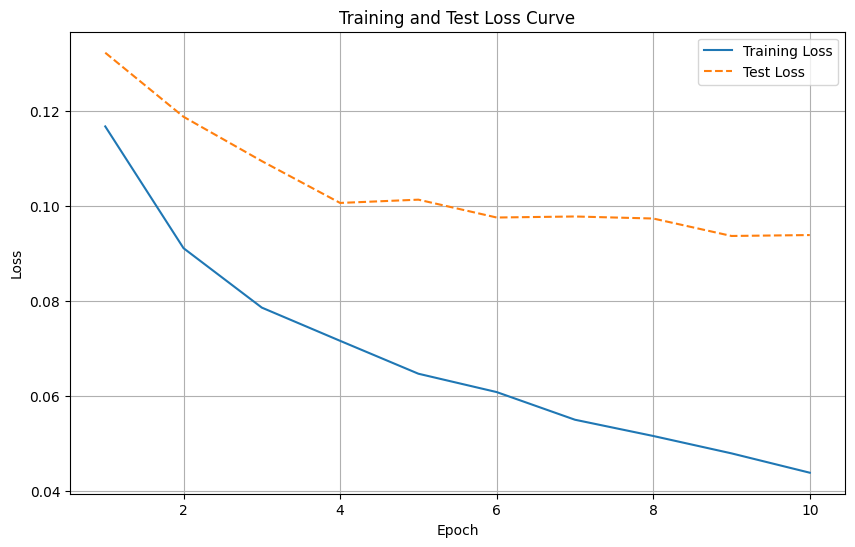

In [110]:
import matplotlib.pyplot as plt

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epoch + 1), train_losses, label='Training Loss')
plt.plot(range(1, epoch + 1), test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

Change to different optimizer: SGD

Epoch [1/10], Train Loss: 0.3413, Test Loss: 0.2511
Epoch [2/10], Train Loss: 0.1695, Test Loss: 0.1862
Epoch [3/10], Train Loss: 0.1275, Test Loss: 0.1599
Epoch [4/10], Train Loss: 0.1082, Test Loss: 0.1463
Epoch [5/10], Train Loss: 0.0972, Test Loss: 0.1382
Epoch [6/10], Train Loss: 0.0894, Test Loss: 0.1337
Epoch [7/10], Train Loss: 0.0841, Test Loss: 0.1300
Epoch [8/10], Train Loss: 0.0800, Test Loss: 0.1261
Epoch [9/10], Train Loss: 0.0768, Test Loss: 0.1240
Epoch [10/10], Train Loss: 0.0740, Test Loss: 0.1223


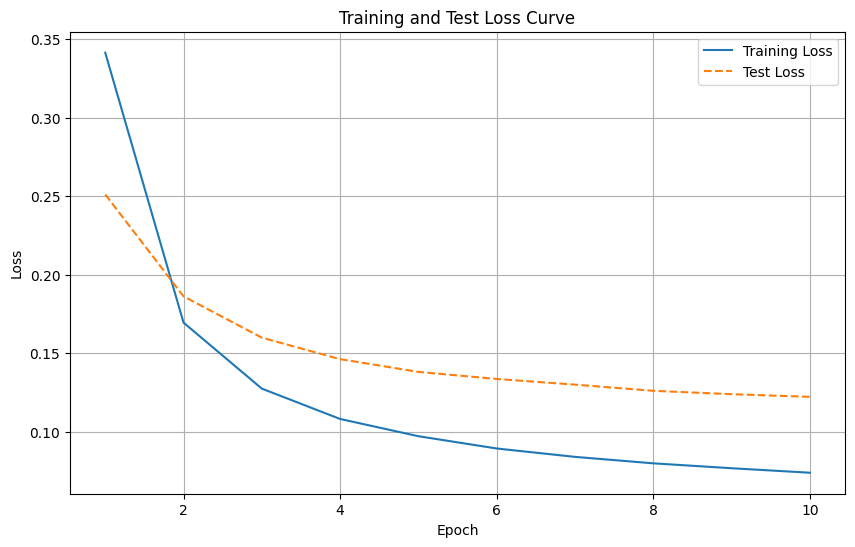

In [114]:
import torch.optim as optim

model_new_optimizer = ClassificationNet(input_units=30, hidden_units=64, output_units=2)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_new_optimizer.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)

epochs = 10
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training phase
    model_new_optimizer.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_new_optimizer(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Evaluation phase on test set
    model_new_optimizer.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            test_outputs = model_new_optimizer(X_batch)
            loss = criterion(test_outputs, y_batch)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

import matplotlib.pyplot as plt

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()